In [3]:
!pip install keras tensorflow

In [4]:
"""NOTES: Batch data is different each time in keras, which result in slight differences in results.
Here is the file tests with BAFNet model. The original code was shown below"""

"""Bettycxh, "Bottleneck-Attention-Based-Fusion-Network-for-Sleep-Apnea-Detection,
" GitHub repository, n.d. [Online]. 
Available: https://github.com/Bettycxh/Bottleneck-Attention-Based-Fusion-Network-for-Sleep-Apnea-Detection
"""
import time
import pickle
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from keras.layers import Conv1D, Dense, Dropout, MaxPooling1D,Reshape,multiply,Permute,\
              GlobalAveragePooling1D,BatchNormalization,Flatten,UpSampling1D,Conv1DTranspose,\
                Flatten,  Lambda, Input
from keras.models import Model,load_model
from keras.regularizers import l2
from scipy.interpolate import splev, splrep
from keras.activations import sigmoid
from keras.callbacks import LearningRateScheduler,ModelCheckpoint
from keras.utils import to_categorical
from IPython.display import SVG,display,HTML
from keras.utils import model_to_dot
import keras.backend as K
from sklearn.metrics import confusion_matrix,f1_score,roc_auc_score
import random
from sklearn.model_selection import train_test_split
import math
import tensorflow as tf

In [5]:
from scipy.interpolate import CubicSpline
def interpolate_numpy_array(arr, desired_length):
    cs = CubicSpline(np.linspace(0, 1, len(arr)), arr)
    x_new = np.linspace(0, 1, desired_length)
    interpolated_arr = cs(x_new)
    return interpolated_arr

# Load data

In [6]:
base_dir = "dataset/1.0.0"
os.environ["CUDA_VISIBLE_DEVICES"]="0,1"
ir = 3 # interpolate interval
before = 2
after = 2
# normalize
scaler = lambda arr: (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
def load_data():
    tm = np.arange(0, (before + 1 + after) * 60, step=1 / float(ir))

    with open(os.path.join(base_dir, "T_1.pkl"), 'rb') as f: # read preprocessing result
        apnea_ecg = pickle.load(f)
    x,x_train,x_val = [],[],[]
    o_train, y_train = apnea_ecg["o_train"], apnea_ecg["y_train"]
    groups_train = apnea_ecg["groups_train"]
    for i in range(len(o_train)):
        min_distance_list, max_distance_list, mean_distance_list = o_train[i]
		# Curve interpolation
        min_distance_list_inter = interpolate_numpy_array(min_distance_list,900)
        max_distance_list_inter = interpolate_numpy_array(max_distance_list,900)
        mean_distance_list_inter = interpolate_numpy_array(mean_distance_list,900)

        x.append([min_distance_list_inter, max_distance_list_inter])
    groups_training,groups_val=[],[]

    num=[i for i in range(16713)]
    trainlist, vallist,y_train, y_val = train_test_split(num,y_train, test_size=0.3,random_state=42,stratify =y_train)
    print()
    for i in trainlist:
        x_train.append(x[i])
        groups_training.append(groups_train[i])
    for i in vallist:
        x_val.append(x[i])
        groups_val.append(groups_train[i])

    x_train = np.array(x_train, dtype="float32").transpose((0, 2, 1)) # convert to numpy format
    y_train= np.array(y_train, dtype="float32")
    x_val = np.array(x_val, dtype="float32").transpose((0, 2, 1)) # convert to numpy format
    y_val = np.array(y_val, dtype="float32")

    x_test = []
    o_test, y_test = apnea_ecg["o_test"], apnea_ecg["y_test"]
    groups_test = apnea_ecg["groups_test"]
    for i in range(len(o_test)):
        min_distance_list, max_distance_list, standard_deviation_distance_list = o_test[i]
		# Curve interpolation
        min_distance_list_inter = interpolate_numpy_array(min_distance_list,900)
        max_distance_list_inter = interpolate_numpy_array(max_distance_list,900)
        mean_distance_list_inter = interpolate_numpy_array(mean_distance_list,900)
        x_test.append([min_distance_list_inter, max_distance_list_inter])
    x_test = np.array(x_test, dtype="float32").transpose((0, 2, 1))
    y_test = np.array(y_test, dtype="float32")

    return x_train,y_train, groups_training,x_val, y_val, groups_val, x_test, y_test, groups_test

In [7]:
from keras.utils import to_categorical

# Load your data
x_train, y_train, groups_train, x_val, y_val, groups_val, x_test, y_test, groups_test = load_data()

# Use to_categorical directly instead of np_utils.to_categorical
y_train = to_categorical(y_train, num_classes=2) 
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)
print('input_shape',x_train.shape)
#rri_train: min_distance_list_inter
#ampl_train: max_distance_list_inter
#We only change the input in the original 
rri_train=np.expand_dims(x_train[:,:,0],axis=2)
ampl_train=np.expand_dims(x_train[:,:,1],axis=2)
rri_val=np.expand_dims(x_val[:,:,0],axis=2)
ampl_val=np.expand_dims(x_val[:,:,1],axis=2)
rri_test=np.expand_dims(x_test[:,:,0],axis=2)
ampl_test=np.expand_dims(x_test[:,:,1],axis=2)


input_shape (11699, 900, 2)


# BAFNet

In [8]:
class ScaledDotProductAttention(keras.layers.Layer):
    def __init__(self,
                 return_attention=False,
                 history_only=False,
                 **kwargs):
        super(ScaledDotProductAttention, self).__init__(**kwargs)
        self.supports_masking = True
        self.return_attention = return_attention
        self.history_only = history_only
        self.intensity = self.attention = None

    def get_config(self):
        config = {
            'return_attention': self.return_attention,
            'history_only': self.history_only,
        }
        base_config = super(ScaledDotProductAttention, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    def compute_output_shape(self, input_shape):
        if isinstance(input_shape, list):
            query_shape, key_shape, value_shape = input_shape
        else:
            query_shape = key_shape = value_shape = input_shape

        output_shape = query_shape[:-1] + value_shape[-1:]

        if self.return_attention:
            attention_shape = query_shape[:2] + (key_shape[1],)
            return [output_shape, attention_shape]

        return output_shape

    def compute_mask(self, inputs, mask=None):
        if isinstance(mask, list):
            mask = mask[0]
        if self.return_attention:
            return [mask, None]
        return mask

    # ✅ NOW PROPERLY INSIDE CLASS
    def call(self, inputs, mask=None, **kwargs):

        q, k, v = inputs

        feature_dim = tf.cast(tf.shape(q)[-1], dtype=tf.float32)
        scores = tf.matmul(q, k, transpose_b=True) / tf.sqrt(feature_dim)

        if mask is not None:
            if isinstance(mask, list):
                actual_mask = mask[1]
            else:
                actual_mask = mask

            if actual_mask is not None:
                actual_mask = tf.cast(actual_mask, dtype=scores.dtype)
                scores += (1.0 - actual_mask) * -1e9

        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, v)

        if self.return_attention:
            return [output, weights]

        return output


In [9]:
def create_model(input_shape,weight=1e-3):
    inp=Input(shape=input_shape)
    input1 =Reshape((900, 1))(inp[:,:,0])
    input2 = Reshape((900, 1))(inp[:,:,1])

    x1 = Conv1D(16, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(weight), bias_regularizer=l2(weight))(input1)
    x2 = Conv1D(16, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(weight), bias_regularizer=l2(weight))(input2)

    x1 = Conv1D(24, kernel_size=11, strides=2, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x1)
    x1 = MaxPooling1D(pool_size=3, padding="same")(x1)
    x2 = Conv1D(24, kernel_size=11, strides=2, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x2)
    x2 = MaxPooling1D(pool_size=3, padding="same")(x2)
    fsn2=keras.layers.concatenate([x1, x2], name="fsn2", axis=-1)

    x1 = Conv1D(32 , kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x1)
    x1 = MaxPooling1D(pool_size=5, padding="same")(x1)
    x2 = Conv1D(32, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x2)
    x2 = MaxPooling1D(pool_size=5, padding="same")(x2)
    fsn3=Conv1D(32, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                  kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(fsn2)
    fsn3=MaxPooling1D(pool_size=5, padding="same")(fsn3)
    fsn3=ScaledDotProductAttention()([fsn3,fsn3,fsn3])
    x1=ScaledDotProductAttention()([fsn3,x1,x1])
    x2=ScaledDotProductAttention()([fsn3,x2,x2])

    # concat
    concat = keras.layers.concatenate([x1, x2], name="Concat_Layer_x1", axis=-1)

    # FCN_1
    FCN1 = UpSampling1D(5)(x1)
    FCN1 = Conv1DTranspose(24, kernel_size=11, strides=1, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(FCN1)
    FCN1 = UpSampling1D(3)(FCN1)
    FCN1 = Conv1DTranspose(16, kernel_size=11, strides=2, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(FCN1)
    FCN1 = Conv1DTranspose(1, kernel_size=11, strides=1, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight),name='rri')(FCN1)

    # FCN_2
    FCN2 = UpSampling1D(5)(x2)
    FCN2 = Conv1DTranspose(24, kernel_size=11, strides=1, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(FCN2)
    FCN2 = UpSampling1D(3)(FCN2)
    FCN2 = Conv1DTranspose(16, kernel_size=11, strides=2, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(FCN2)
    FCN2 = Conv1DTranspose(1, kernel_size=11, strides=1, padding="same", kernel_initializer="he_normal",
                              kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight),name='ampl')(FCN2)

    #Channel-wise fusion module
    squeeze = GlobalAveragePooling1D()(concat)
    excitation=Dense(32,activation='relu')(squeeze)
    excitation=Dense(64,activation='sigmoid')(excitation)
    excitation = Reshape((1, 64))(excitation)
    scale = multiply([concat, excitation])

    # Classification
    x = GlobalAveragePooling1D(name='GAP')(scale)
    outputs=Dense(2,activation='softmax',name="outputs")(x)
    model = Model(inputs=inp, outputs=[outputs,FCN1,FCN2])
    return model

# Training stage 1

In [12]:
def lr_schedule(epoch, lr):
    if epoch > 70 and (epoch - 1) % 10 == 0:
        lr *= 0.1
    print("Learning rate: ", lr)
    return lr

def plot(history):
    """Plot performance curve"""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    print(history)
    axes[0].plot(history["outputs_loss"], "r-", history["val_outputs_loss"], "b-", linewidth=0.5)
    axes[0].set_title("Loss")
    axes[1].plot(history["outputs_accuracy"], "r-", history["val_outputs_accuracy"], "b-", linewidth=0.5)
    axes[1].set_title("Accuracy")
    fig.tight_layout()
    fig.show()

2026-02-18 02:45:29.134836: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
False
False
False
Learning rate:  0.0010000000474974513
Epoch 1/100
92/92 [==============================] - ETA: 0s - loss: 1.7194 - outputs_loss: 0.6734 - rri_loss: 0.0817 - ampl_loss: 0.3875 - outputs_accuracy: 0.6035
Epoch 1: val_outputs_accuracy improved from -inf to 0.61249, saving model to /home/durgesh/Satyam/new/MPCNN-Sleep-Apnea/output/best_model.keras
92/92 [==============================] - 7s 40ms/step - loss: 1.7194 - outputs_loss: 0.6734 - rri_loss: 0.0817 - ampl_loss: 0.3875 - outputs_accuracy: 0.6035 - val_loss: 1.2479 - val_outputs_loss: 0.6647 - val_rri_loss: 0.0135 - val_ampl_loss: 0.0472 - val_outputs_accuracy: 0.6125 - lr: 0.0010
Learning rate:  0.0010000000474974513
Epoch 2/100
92/92 [==============================] - ETA: 0s - loss: 1.2147 - outputs_loss: 0.6625 - rri_loss: 0.0129 - ampl_loss: 0.0452 - outputs_accuracy: 0.6126
Epoch 2: val_outputs_accuracy did not improve from 0.61249
92/92 

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Final Result/Final_performance/BAFNet'

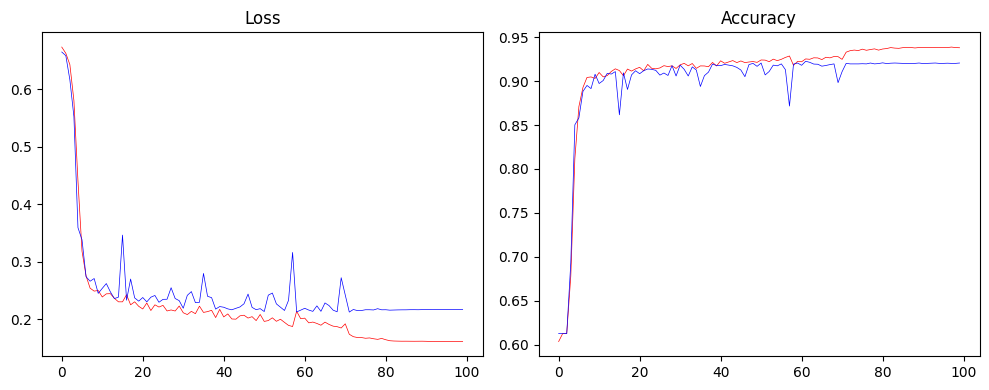

In [ ]:
"""Please change the filepath of your device to save the result"""
if __name__ == "__main__":

    # Create model
    model = create_model(x_train.shape[1:])

    # Compile
    model.compile(
    optimizer='adam',
    loss=[
        tf.keras.losses.CategoricalCrossentropy(),  # output[0] → classification
        tf.keras.losses.MeanSquaredError(),         # output[1] → rri
        tf.keras.losses.MeanSquaredError()          # output[2] → ampl
    ],
    loss_weights=[1.0, 1.0, 1.0],
    metrics=[['accuracy'], [], []]
)

    # Callbacks
    filepath = '/home/durgesh/Satyam/new/MPCNN-Sleep-Apnea/output/best_model.keras'
    checkpoint = ModelCheckpoint(
        filepath,
        monitor='val_outputs_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max'
    )
    lr_scheduler = LearningRateScheduler(lr_schedule)
    callbacks_list = [lr_scheduler, checkpoint]
    print(type(y_train))
    print(type(rri_train))
    print(type(ampl_train))

    print(isinstance(y_train, (list, tuple)))
    print(isinstance(rri_train, (list, tuple)))
    print(isinstance(ampl_train, (list, tuple)))

    # Train
    time_begin = time.time()
    history = model.fit(
        x_train,
        [y_train, rri_train, ampl_train],   # ✅ FIXED ORDER
        batch_size=128,
        epochs=100,
        validation_data=(x_val, [y_val, rri_val, ampl_val]),
        callbacks=callbacks_list
    )
    time_end = time.time()
    print('time_train:', time_end - time_begin)

    plot(history.history)

    # Evaluate
    r = model.evaluate(x_test, [y_test, rri_test, ampl_test])
    loss = r[0]
    acc = r[1]   # outputs_accuracy

    # Predict
    y_score = model.predict(x_test, batch_size=1024, verbose=1)[0]

    roc = roc_auc_score(y_true=y_test[:, 1], y_score=y_score[:, 1])

    output = pd.DataFrame({
        "y_true": y_test[:, 1],
        "y_score": y_score[:, 1],
        "subject": groups_test
    })

    output.to_csv(
        "/content/drive/MyDrive/Final Result/Final_performance/BAFNet/file_name.csv",
        index=False
    )

    # Confusion matrix
    y_pred = np.argmax(y_score, axis=-1)
    y_true = np.argmax(y_test, axis=-1)

    C = confusion_matrix(y_true, y_pred, labels=(1, 0))
    TP, TN, FP, FN = C[0, 0], C[1, 1], C[1, 0], C[0, 1]

    acc = (TP + TN) / (TP + TN + FP + FN)
    sn = TP / (TP + FN + 1e-8)
    sp = TN / (TN + FP + 1e-8)
    f1 = f1_score(y_true, y_pred, average='binary')

    print(
        "TP:{}, TN:{}, FP:{}, FN:{}, loss:{:.4f}, acc:{:.4f}, "
        "sn:{:.4f}, sp:{:.4f}, f1:{:.4f}, roc:{:.4f}".format(
            TP, TN, FP, FN, loss, acc, sn, sp, f1, roc
        )
    )


In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get model predictions (classification output only)
y_pred_prob = model.predict(x_test, batch_size=1024, verbose=1)[0]

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)


17/17 [==============================] - 1s 46ms/step


In [15]:
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
TP, FN = cm[0]
FP, TN = cm[1]

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[5688  803]
 [ 639 9816]]


In [16]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN)      # Recall
specificity = TN / (TN + FP)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")


Accuracy    : 0.9149
Sensitivity : 0.8763
Specificity : 0.9389
